# Seq2Seq 모델 Q&A Chatbot 구현

1. QnA 데이터셋을 찾아서 처리해서 준비한다. (전처리 전반)
2. Encoder, Decoder, Seq2Seq(Encoder+Decoder) 모델을 만든다.
3. 1에서 준비한 데이터로 2에서 만든 모델을 학습시킨다.
4. Chatbot을 만든다. (모델 추론 + while문)

### 데이터 로드

In [87]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [88]:
# local용 filepath
digital_df = pd.read_csv('/Users/kimunoo/SKN24/nlp_practice/data/sbo_qna/Training/sbo_qna_train/디지털가전_train.csv', encoding='utf-8')

# colab용 filepath
# digital_df = pd.read_csv('/content/sbo_qun/디지털가전_train.csv', encoding='utf-8')

digital_df.info()
digital_df = digital_df[['발화자', '발화문']]
digital_df.to_csv('sbo_digital_qna.csv', index=False, encoding='utf-8-sig')

/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/ipykernel_28072/61469609.py:2: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  digital_df = pd.read_csv('/Users/kimunoo/SKN24/nlp_practice/data/sbo_qna/Training/sbo_qna_train/디지털가전_train.csv', encoding='utf-8')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742995 entries, 0 to 742994
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   IDX     742995 non-null  int64 
 1   발화자     742995 non-null  object
 2   발화문     742995 non-null  object
 3   카테고리    742995 non-null  object
 4   QA번호    742995 non-null  int64 
 5   QA여부    742995 non-null  object
 6   감성      742995 non-null  object
 7   인텐트     742995 non-null  object
 8   가격      14038 non-null   object
 9   수량      19132 non-null   object
 10  크기      26983 non-null   object
 11  장소      8065 non-null    object
 12  조직      27984 non-null   object
 13  사람      349 non-null     object
 14  시간      575 non-null     object
 15  날짜      45050 non-null   object
 16  상품명     272932 non-null  object
 17  상담번호    742995 non-null  int64 
 18  상담내순번   742995 non-null  int64 
dtypes: int64(4), object(15)
memory usage: 107.7+ MB


In [89]:
display(digital_df.head(100))

,발화자,발화문
0,c,아 그래요?
1,s,네 지금 이제품이 베스트 제품인데요
2,s,컬러가 들어가서 화사해서 여성분들이 많이 좋아하세요
3,s,김치냉장고 겸용말고 그냥 김치 냉장고만 찾으시는?
4,c,네 그냥 김치만 넣을수 잇는
...,...,...
95,c,그거 전부 날리셔도 됩니다
96,c,데스크탑은 뭐 급한건도 아니고요
97,s,아 그렇군요
98,c,아 제가 잘몰라서 이것 저것 물어봐요 죄송합니다


### 전처리 - 일단 정제와 묶어주기

In [90]:
ko_stopwords = [
"아","휴","아이구","아이쿠","아이고","어","나","우리","저희","따라","의해","을","를","에","의","가","으로","로","에게",
"뿐이다","의거하여","근거하여","입각하여","기준으로","예하면","예를 들면","예를 들자면","저","소인","소생","저희",
"지말고","하지마","하지마라","다른","물론","또한","그리고","비길수 없다","해서는 안된다","뿐만 아니라","만이 아니다",
"만은 아니다","막론하고","관계없이","그치지 않다","그러나","그런데","하지만","든간에","논하지 않다","따지지 않다",
"설사","비록","더라도","아니면","만 못하다","하는 편이 낫다","불문하고","향하여","향해서","향하다","쪽으로","틈타",
"이용하여","타다","오르다","제외하고","이 외에","이 밖에","하여야","비로소","한다면 몰라도","외에도","이곳","여기",
"부터","기점으로","따라서","할 생각이다","하려고하다","이리하여","그리하여","그렇게 함으로써","일때","할때",
"앞에서","중에서","보는데서","으로써","로써","까지","해야한다","일것이다","반드시","할줄알다","할수있다",
"할수있어","임에 틀림없다","한다면","등","등등","제","겨우","단지","다만","할뿐","딩동","댕그","대해서",
"대하여","대하면","훨씬","얼마나","얼마만큼","얼마큼","남짓","여","얼마간","약간","다소","좀","조금","다수",
"몇","얼마","지만","하물며","또한","그러나","그렇지만","하지만","이외에도","대해 말하자면","뿐이다","다음에",
"반대로","반대로 말하자면","이와 반대로","바꾸어서 말하면","바꾸어서 한다면","만약","그렇지않으면","까악","툭",
"딱","삐걱거리다","보드득","비걱거리다","꽈당","응당","해야한다","에 가서","각","각각","여러분","각종",
"각자","제각기","하도록하다","와","과","그러므로","그래서","고로","한 까닭에","하기 때문에","거니와",
"이지만","대하여","관하여","관한","과연","실로","아니나다를가","생각한대로","진짜로","한적이있다",
"하곤하였다","하","하하","허허","아하","거바","와","오","왜","어째서","무엇때문에","어찌","하겠는가",
"무슨","어디","어느곳","더군다나","하물며","더욱이는","어느때","언제","야","이봐","어이","여보시오",
"흐흐","흥","휴","헉헉","헐떡헐떡","영차","여차","어기여차","끙끙","아야","앗","아야","콸콸","졸졸",
"좍좍","뚝뚝","주룩주룩","솨","우르르","그래도","또","그리고","바꾸어말하면","바꾸어말하자면","혹은",
"혹시","답다","및","그에 따르는","때가 되어","즉","지든지","설령","가령","하더라도","할지라도",
"일지라도","몇","거의","하마터면","인젠","이젠","된바에야","된이상","만큼","어찌됏든","그위에",
"게다가","점에서 보아","비추어 보아","고려하면","하게될것이다","비교적","보다더","비하면",
"시키다","하게하다","할만하다","의해서","연이서","이어서","잇따라","뒤따라","뒤이어","결국",
"의지하여","기대여","통하여","자마자","더욱더","불구하고","얼마든지","마음대로","주저하지 않고",
"곧","즉시","바로","당장","하자마자","밖에 안된다","하면된다","그래","그렇지","요컨대",
"다시 말하자면","바꿔 말하면","구체적으로","말하자면","시작하여","시초에","이상","허","헉","허걱",
"바와같이","해도좋다","해도된다","더구나","와르르","팍","퍽","펄렁","동안","이래",
"하고있었다","이었다","에서","로부터","함께","같이","더불어","마저","마저도","양자","모두",
"습니다","가까스로","즈음하여","다른 방면으로","해봐요","습니까","했어요","말할것도 없고",
"무릎쓰고","개의치않고","하는것만 못하다","하는것이 낫다","매","매번","들","모",
"어느것","어느","갖고말하자면","어느쪽","어느해","어느 년도","라 해도","언젠가",
"어떤것","저기","저쪽","저것","그때","그럼","그러면","요만한걸","저것만큼",
"그저","이르기까지","할 줄 안다","할 힘이 있다","너","너희","당신","설마","차라리",
"할지언정","할망정","구토하다","게우다","토하다","메쓰겁다","옆사람","퉤","쳇",
"힘입어","그","다음","버금","두번째로","기타","첫번째로","나머지는","그중에서",
"견지에서","형식으로 쓰여","입장에서","위해서","의해되다","하도록시키다","뿐만아니라",
"전후","전자","앞의것","잠시","잠깐","하면서","그러한즉","그런즉","남들","아무거나",
"어찌하든지","같다","비슷하다","예컨대","이럴정도로","어떻게","만일","위에서 서술한바와같이",
"인 듯하다","하지 않는다면","만약에","무엇","어느","어떤","아래윗","조차","한데",
"그럼에도 불구하고","여전히","심지어","까지도","조차도","하지 않도록","않기 위하여",
"때","시각","무렵","시간","어때","어떠한","하여금","네","예","우선","누구",
"누가 알겠는가","아무도","줄은모른다","줄은 몰랏다","하는 김에","겸사겸사","하는바",
"그런 까닭에","한 이유는","그러니","그러니까","때문에","그들","너희들","타인","것","것들",
"위하여","공동으로","동시에","하기 위하여","어찌하여","붕붕","윙윙","엉엉","휘익",
"오호","어쨋든","하기보다는","놀라다","상대적으로 말하자면","마치","아니라면","쉿",
"그렇지 않으면","그렇지 않다면","안 그러면","아니었다면","하든지","이라면","좋아",
"알았어","하는것도","그만이다","어쩔수 없다","하나","일","일반적으로","일단",
"한켠으로는","오자마자","이렇게되면","이와같다면","전부","한마디","한항목",
"근거로","하기에","아울러","않기 위해서","이 되다","로 인하여","까닭으로",
"이유만으로","이로 인하여","이 때문에","알 수 있다","결론을 낼 수 있다",
"으로 인하여","있다","관계가 있다","관련이 있다","연관되다","에 대해","여부",
"하느니","하면 할수록","운운","이러이러하다","하구나","하도다","다시말하면",
"다음으로","에 있다","에 달려 있다","우리들","오히려","하기는한데",
"어떻해","어찌됏어","본대로","자","이","이쪽","이것","이번",
"이렇게말하자면","이런","이러한","이와 같은","요만큼","요만한 것",
"얼마 안 되는 것","이만큼","이 정도의","이렇게 많은 것",
"이와 같다","이때","이렇구나","것과 같이","끼익","삐걱",
"따위","와 같은 사람들","부류의 사람들","왜냐하면","중의하나",
"오직","오로지","에 한하다","하기만 하면","도착하다",
"까지 미치다","도달하다","정도에 이르다","할 지경이다",
"결과에 이르다","관해서는","하고 있다","한 후","혼자",
"자기","자기집","자신","우에 종합한것과같이","총적으로 보면",
"총적으로 말하면","총적으로","대로 하다","으로서","참",
"할 따름이다","쿵","탕탕","쾅쾅","둥둥","봐","봐라",
"아이야","아니","와아","응","아이","참나","년","월","일",
"령","영","이","삼","사","오","육","륙","칠","팔","구",
"이천육","이천칠","이천팔","이천구","하나","둘","셋","넷",
"다섯","여섯","일곱","여덟","아홉"
]

len(ko_stopwords)

611

In [91]:
import re

def clean_text(text):
    # 1. 문자가 아닌 경우(NaN 등) 빈 문자열로 처리
    if not isinstance(text, str):
        return ""

    # 2. 한글과 공백만 남기고 제거 (특수문자, 숫자 등 삭제)
    text = re.sub(r'[^가-힣\s]', '', text)

    # 3. 양끝 공백 제거
    text = text.strip()

    return text


digital_df['발화문'] = digital_df['발화문'].apply(clean_text)

# 결과 확인 (빈 문자열이 된 행이 있을 수 있으니 다시 한번 체크)
digital_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742995 entries, 0 to 742994
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   발화자     742995 non-null  object
 1   발화문     742995 non-null  object
dtypes: object(2)
memory usage: 11.3+ MB


### 전처리 - 불용어 및 c,s 합치기

In [92]:
# 한국어 불용어 리스트
# 추임새 및 감탄사, 지시어 및 대명사, 의미 없는 어미/접사 등

ko_stopwords = [
    "아", "어", "음", "오", "으", "어어", "음음",
    "네", "네네", "예", "예예",
    "아니", "아니요",
    "그", "그냥", "그게", "그거", "그것", "그래", "그래서",
    "저", "저기", "저거", "저것",
    "이", "이거", "이것", "이게", "이쪽",
    "여기", "저기", "거기",
    "음...", "어...", "아...",
    "뭐", "뭐지", "뭐랄까",
    "약간", "좀", "조금",
    "막", "되게", "진짜",
    "그러니까", "그러면", "그래가지고",
    "아무튼", "어쨌든",
    "그런데", "근데",
    "맞아요", "맞아요", "맞네",
    "있잖아요", "있잖아",
    "그렇죠", "그쵸", "그죠",
    "요", "죠",
    "가요", "네요", "하네요",
    "같아요", "같은데",
    "아마", "약간요"
]

In [93]:
from konlpy.tag import Okt

okt = Okt()

# 토큰화 및 불용어 제거 함수
# 자연스러운 한국어 구사를 원하면 조사 넣기

def tokenize_and_filter(text):
    # 조사 제거 X
    tokens = okt.morphs(text)
    filtered = [word for word in tokens if word not in ko_stopwords]

    # 조사 제거 O
    # pos_tagged = okt.pos(text)  # pos()를 사용하면 (단어, 품사)의 튜플 리스트가 반환 / [('노트북', 'Noun'), ('이', 'Josa'), ('비싸요', 'Adjective')]
    # filtered = [word for word, pos in pos_tagged if pos != 'Josa' and word not in ko_stopwords]

    return " ".join(filtered)


In [94]:
# 전처리 함수 작성
# 연속적인 c, s 하나로 합치기 + 한국어 불용어 제거

def preprocess_data(df):
    question_inputs = []  # Encoder Input (C)
    answer_inputs = []    # Decoder Input (S + <sos>)
    answer_targets = []   # Decoder Target (S + <eos>)

    # 연속된 발화 합치기 (c-c-c 이어지면 하나로, s-s-s 이어지면 하나로)
    dialogue_turns = []
    current_speaker = None
    current_text = ""

    for _, row in df.iterrows():
        speaker = row['발화자']
        text = str(row['발화문']).strip()

        if speaker == current_speaker:
            current_text += " " + text
        else:
            if current_speaker is not None:
                dialogue_turns.append({'speaker': current_speaker, 'text': current_text})
            current_speaker = speaker
            current_text = text

    if current_text:
        dialogue_turns.append({'speaker': current_speaker, 'text': current_text})



    for i in range(len(dialogue_turns) - 1):
        # c-s 쌍 확인
        if dialogue_turns[i]['speaker'] == 'c' and dialogue_turns[i+1]['speaker'] == 's':
            # 질문과 답변을 각각 Okt로 토큰화
            q_text = tokenize_and_filter(dialogue_turns[i]['text'])
            a_text = tokenize_and_filter(dialogue_turns[i+1]['text'])

            # 토큰화된 결과가 비어있지 않은 경우에만 추가
            if q_text and a_text:
                question_inputs.append(q_text)
                answer_inputs.append('<sos> ' + a_text)
                answer_targets.append(a_text + ' <eos>')

    return question_inputs, answer_inputs, answer_targets



# 실행 예시
# q_inp, a_inp, a_tar = prepare_seq2seq_data(df)

# 확인용
# print(f"질문 예시: {q_inp[0]}")
# print(f"디코더 입력 예시: {a_inp[0]}")
# print(f"디코더 타겟 예시: {a_tar[0]}")

### 전처리 함수 적용

In [102]:
# 전체 데이터셋 742995건 / 로커 cpu에서 29분
# question_inputs, answer_inputs, answer_targets = preprocess_data(digital_df)

# 일부 데이터셋
df_subset = digital_df.iloc[:100000]
question_inputs, answer_inputs, answer_targets = preprocess_data(df_subset)

KeyboardInterrupt: 

In [ ]:
# 데이터 전처리 파일 저장
import pickle

# 저장하기 (Write Binary)

# 전체 데이터 74만건
# with open('data/sbo_qna/preprocessed_data/data_withjosa.pkl', 'wb') as f:
#     pickle.dump({
#         'q_inputs': question_inputs,
#         'a_inputs': answer_inputs,
#         'a_targets': answer_targets
#     }, f)

with open('data/sbo_qna/preprocessed_data/data_withjosa_100t.pkl', 'wb') as f:
    pickle.dump({
        'q_inputs': question_inputs,
        'a_inputs': answer_inputs,
        'a_targets': answer_targets
    }, f)

In [103]:
# 📂 불러오기 (Read Binary)
with open('data/sbo_qna/preprocessed_data/data_withjosa_100t.pkl', 'rb') as f:
    data = pickle.load(f)
    question_inputs = data['q_inputs']
    answer_inputs = data['a_inputs']
    answer_targets = data['a_targets']

In [ ]:
# question_inputs[1000:1010]
# answer_inputs[1000:1010]
# answer_targets[1000:1010]

['삼성 최고 <eos>',
 '퍼플 있어요 <eos>',
 '그럼 제품 추천 합니다 <eos>',
 '회사 마다 다른데 삼성 같은 경우 에 비 스포크 많이 나가고요 <eos>',
 '는 용량 리터 정도 괜찮을거 <eos>',
 '삼 백 리터 정도 되는게 잘 나가요 키로 보셔야겠네요 <eos>',
 '비슷하게 나가요 <eos>',
 '그건 고객 님 따라 달라 용량 많으면 많은거로 하시고요 주 소 시 면 은 인치 를 많이 들 하세요 <eos>',
 '모델 어떠세요 <eos>',
 '은은한 거 면 장미 향기 추천 드리고요 섬유 유연제 처럼 그렇게 세지 않아요 겨울 에 미세먼지 도 많고 하니까 외투 도 보관 하시기 좋을거에요 세벌 보다는 다섯 벌 추천 해드릴게요 <eos>']

In [104]:
# 전처리 후 단어 빈도수 및 전체 사이즈 확인 코드

from collections import Counter

def check_vocab_stats(q_inputs, a_inputs):
    # 1. 모든 문장을 단어 단위로 합치기
    all_tokens = []
    for sentence in q_inputs + a_inputs:
        # 공백 기준으로 분리 (이미 Okt로 토큰화되어 공백으로 붙여진 상태 가정)
        all_tokens.extend(sentence.split())
    
    # 2. 빈도수 계산
    vocab_counts = Counter(all_tokens)
    total_unique_words = len(vocab_counts)
    
    print(f"✅ 전체 고유 단어(Unique Tokens) 수: {total_unique_words:,}개")
    
    # 3. 빈도수 기준 상위 단어 확인
    print("\n📊 빈도수 상위 20개 단어:")
    for word, count in vocab_counts.most_common(20):
        print(f"{word}: {count:,}번")
        
    # 4. 누적 백분율 확인 (MAX_VOCAB_SIZE 결정 가이드)
    sorted_counts = [count for _, count in vocab_counts.most_common()]
    total_sum = sum(sorted_counts)
    
    print("\n📈 누적 빈도수 비율:")
    for limit in [5000, 10000, 20000, 30000]:
        accumulated_sum = sum(sorted_counts[:limit])
        percentage = (accumulated_sum / total_sum) * 100
        print(f"상위 {limit:,}개 단어 사용 시 전체 데이터의 {percentage:.2f}% 커버")

# 실행 예시
check_vocab_stats(question_inputs, answer_inputs)

✅ 전체 고유 단어(Unique Tokens) 수: 29,762개

📊 빈도수 상위 20개 단어:
<sos>: 41,536번
은: 18,926번
에: 18,496번
제품: 15,391번
가: 14,663번
는: 13,835번
으로: 12,174번
입고: 12,164번
로: 11,022번
구매: 10,910번
을: 10,175번
사용: 7,840번
수: 7,192번
됩니다: 7,065번
상품: 6,951번
입니다: 6,890번
되나요: 6,706번
언제: 6,687번
를: 6,535번
어떤: 6,411번

📈 누적 빈도수 비율:
상위 5,000개 단어 사용 시 전체 데이터의 94.75% 커버
상위 10,000개 단어 사용 시 전체 데이터의 97.55% 커버
상위 20,000개 단어 사용 시 전체 데이터의 99.13% 커버
상위 30,000개 단어 사용 시 전체 데이터의 100.00% 커버


In [105]:
print(question_inputs[1000:1010])
print(answer_inputs[1000:1010])
print(answer_targets[1000:1010])


print(len(question_inputs), len(answer_inputs), len(answer_targets))

['건조기 는 어디 께 많이 나가요', '다른거 봐야 겠네요', '제품 사진 찍을려고요', '어느 게 잘 나가나요 잘 나가는 모델 어느 거 에요', '그리고 는 어느 게 나아요', '정도 가 낫겠네요', '키 로는 어떤게 잘나가요 위니 삼성 어떤게 많이 나가요', '게 더 쓰기 편한가요 게 더 쓰기 편한가요', '저희 가 크긴 해서 나을거 인치 크긴 크네요', '뭐좀 물어보려고 전화 드렸습니다 하고 세탁기 를 렌탈 하려 하는데 는 인치 추천 할 만 한 게 있나요']
['<sos> 삼성 최고', '<sos> 퍼플 있어요', '<sos> 그럼 제품 추천 합니다', '<sos> 회사 마다 다른데 삼성 같은 경우 에 비 스포크 많이 나가고요', '<sos> 는 용량 리터 정도 괜찮을거', '<sos> 삼 백 리터 정도 되는게 잘 나가요 키로 보셔야겠네요', '<sos> 비슷하게 나가요', '<sos> 그건 고객 님 따라 달라 용량 많으면 많은거로 하시고요 주 소 시 면 은 인치 를 많이 들 하세요', '<sos> 모델 어떠세요', '<sos> 은은한 거 면 장미 향기 추천 드리고요 섬유 유연제 처럼 그렇게 세지 않아요 겨울 에 미세먼지 도 많고 하니까 외투 도 보관 하시기 좋을거에요 세벌 보다는 다섯 벌 추천 해드릴게요']
['삼성 최고 <eos>', '퍼플 있어요 <eos>', '그럼 제품 추천 합니다 <eos>', '회사 마다 다른데 삼성 같은 경우 에 비 스포크 많이 나가고요 <eos>', '는 용량 리터 정도 괜찮을거 <eos>', '삼 백 리터 정도 되는게 잘 나가요 키로 보셔야겠네요 <eos>', '비슷하게 나가요 <eos>', '그건 고객 님 따라 달라 용량 많으면 많은거로 하시고요 주 소 시 면 은 인치 를 많이 들 하세요 <eos>', '모델 어떠세요 <eos>', '은은한 거 면 장미 향기 추천 드리고요 섬유 유연제 처럼 그렇게 세지 않아요 겨울 에 미세먼지 도 많고 하니까 외투 도 보관 하시기 좋을거에요 세벌 보다는 다섯 벌 추천 해드릴게요 <eo

### 전역변수 선언

- 배치 크기, 단어사전 크기, 임베딩 차원, 뉴런수

In [106]:
BATCH_SIZE = 32
MAX_VOCAB_SIZE = 10000
EMBEDDING_DIM = 100
LATENT_DIM = 512

In [107]:
all_texts = question_inputs + answer_inputs + answer_targets

# 같은 한국어이므로 하나의 토크나이저로 모든 텍스트 학습
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters=' ')
tokenizer.fit_on_texts(all_texts)

# 변환
question_seqs = tokenizer.texts_to_sequences(question_inputs)
answer_input_seqs = tokenizer.texts_to_sequences(answer_inputs)
answer_target_seqs = tokenizer.texts_to_sequences(answer_targets)

num_words = len(tokenizer.word_index) + 1
max_len = max(max(len(s) for s in answer_input_seqs), max(len(s) for s in answer_input_seqs))

print(f'{num_words = }')
print(f'{max_len = }')

num_words = 29766
max_len = 201


In [108]:
encoder_inputs = pad_sequences(question_seqs, maxlen=max_len, padding='pre')
decoder_inputs = pad_sequences(answer_input_seqs, maxlen=max_len, padding='post')
decoder_targets = pad_sequences(answer_target_seqs, maxlen=max_len, padding='post')

print(encoder_inputs.shape)
print(decoder_inputs.shape)
print(decoder_targets.shape)

print(encoder_inputs[1000])
print([tokenizer.index_word[s] for s in encoder_inputs[1000] if s != 0])
print(decoder_inputs[1000])
print([tokenizer.index_word[s] for s in decoder_inputs[1000] if s != 0])
print(decoder_targets[1000])
print([tokenizer.index_word[s] for s in decoder_targets[1000] if s != 0])

(41536, 201)
(41536, 201)
(41536, 201)
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0   

### 데이터셋 준비

In [109]:
class MMTDAtaset(Dataset):
  def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
    super().__init__()
    self.encoder_inputs = encoder_inputs
    self.decoder_inputs = decoder_inputs
    self.decoder_targets = decoder_targets

  def __len__(self):
    return len(self.encoder_inputs) # 3개의 길이는 똑같으니 아무거나

  def __getitem__(self, index):
    return(
        torch.tensor(self.encoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_targets[index], dtype=torch.long)
    )

In [110]:
train_index, val_index = train_test_split(range(len(encoder_inputs)), random_state=0)
print(len(train_index), len(val_index))

train_dataset = MMTDAtaset(
    encoder_inputs[train_index],
    decoder_inputs[train_index],
    decoder_targets[train_index]
)
val_dataset = MMTDAtaset(
    encoder_inputs[val_index],
    decoder_inputs[val_index],
    decoder_targets[val_index]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

31152 10384


### Seq2Seq Model

In [111]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, latent_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)

    def forward(self, X):
        X = self.embedding(X)
        output, (h_s, c_s) = self.lstm(X)
        return h_s, c_s

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, latent_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)
        self.fc = nn.Linear(latent_dim, vocab_size)

    def forward(self, X, hidden, cell):
        X = self.embedding(X)
        output, (h_s, c_s) = self.lstm(X, (hidden, cell))
        logits = self.fc(output)
        return logits, h_s, c_s

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target):
        h_s, c_s = self.encoder(source)
        output, h_s, c_s = self.decoder(target, h_s, c_s)
        return output

In [112]:
encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)

model = Seq2Seq(encoder, decoder)

In [113]:
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(29766, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(29766, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=29766, bias=True)
  )
)

In [72]:
# !pip install torchviz graphviz

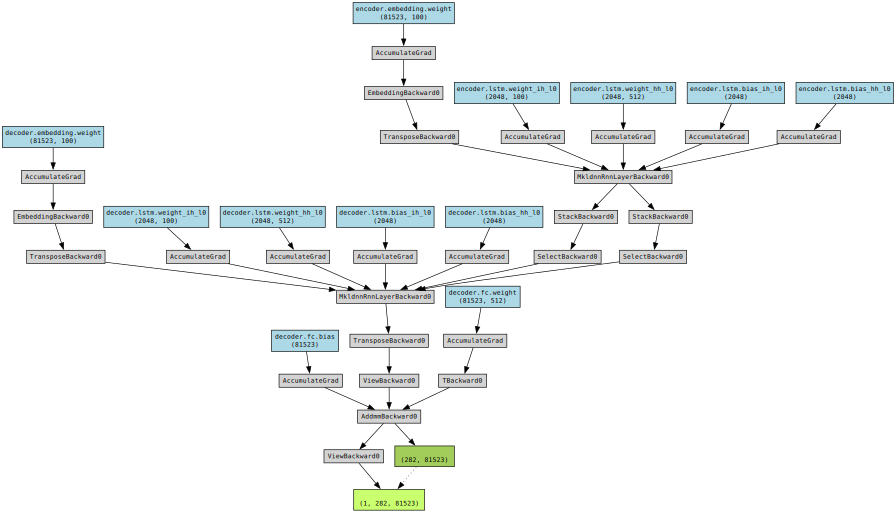

In [73]:
from torchviz import make_dot

source_input = torch.randint(0, num_words, (1, max_len))
target_input = torch.randint(0, num_words, (1, max_len))

out = model(source_input, target_input)

make_dot(out, params=dict(list(model.named_parameters())))
make_dot(out, params=dict(list(model.named_parameters())))

### 모델 학습

In [74]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)
model = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.001)

epochs = 100

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(epochs):
  model.train()
  train_loss, train_correct, train_tokens = 0, 0, 0

  for enc_inputs, dec_inputs, dec_targets in train_loader:
    enc_inputs = enc_inputs.to(device)
    dec_inputs = dec_inputs.to(device)
    dec_targets = dec_targets.to(device)

    optimizer.zero_grad()

    # teacher forcing
    output = model(enc_inputs, dec_inputs)
    output = output.view(-1, output.size(-1))
    dec_targets = dec_targets.view(-1)

    loss = criterion(output, dec_targets)
    loss.backward()
    optimizer.step()

    preds = output.argmax(dim=-1)
    train_loss += loss.detach().cpu().item()
    mask = dec_targets != 0
    correct = (preds == dec_targets) & mask
    train_correct += correct.sum().detach().cpu().item()
    train_tokens += mask.sum().detach().cpu().item()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_tokens
  train_losses.append(train_loss)
  train_accs.append(train_acc)

  model.eval()
  with torch.no_grad():
    val_loss, val_correct, val_tokens = 0, 0, 0

    for enc_inputs, dec_inputs, dec_targets in val_loader:
      enc_inputs = enc_inputs.to(device)
      dec_inputs = dec_inputs.to(device)
      dec_targets = dec_targets.to(device)

      output = model(enc_inputs, dec_inputs)
      output = output.view(-1, output.size(-1))
      dec_targets = dec_targets.view(-1)

      loss = criterion(output, dec_targets)

      preds = output.argmax(dim=-1)
      val_loss += loss.detach().cpu().item()
      mask = dec_targets != 0
      correct = (preds == dec_targets) & mask
      val_correct += correct.sum().detach().cpu().item()
      val_tokens += mask.sum().detach().cpu().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_tokens
    val_losses.append(val_loss)
    val_accs.append(val_acc)

  print(f'Epoch {epoch+1}/{epochs} TrainLoss={train_loss:.4f} TrainAcc={train_acc:.4f} ValLoss={val_loss:.4f} ValAcc={val_acc:.4f}')

/opt/miniconda3/envs/nlp_stable/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

### 모델 저장

In [ ]:
torch.save(model, 'seq2seq_chatbot.pth')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs,
}).plot()
plt.show()

### 모델 불러오기

In [ ]:
# 완료되면 모델 불러오기
# model = torch.load('seq2seq_chatbot.pth', weights_only=False)
# model

In [114]:
# 완료되기 전에 state_dict만 있다면 같은 구조 model 생성
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, latent_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)

    def forward(self, X):
        X = self.embedding(X)
        output, (h_s, c_s) = self.lstm(X)
        return h_s, c_s

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, latent_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)
        self.fc = nn.Linear(latent_dim, vocab_size)

    def forward(self, X, hidden, cell):
        X = self.embedding(X)
        output, (h_s, c_s) = self.lstm(X, (hidden, cell))
        logits = self.fc(output)
        return logits, h_s, c_s

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target):
        h_s, c_s = self.encoder(source)
        output, h_s, c_s = self.decoder(target, h_s, c_s)
        return output

In [115]:
encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)

model = Seq2Seq(encoder, decoder)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(29766, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(29766, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=29766, bias=True)
  )
)

In [116]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

path = '/Users/kimunoo/SKN24/nlp_practice/data/sbo_qna/model_state/chatbot_model_ep9.pth'
checkpoint = torch.load(path, map_location=device)

# 모델에 가중치 주입하기
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"{checkpoint['epoch']} epoch 지점부터 복구 완료")
# 만약 순수하게 가중치(state_dict)만 저장된 파일이라면:
else:
    model.load_state_dict(checkpoint)
    print("모델 가중치 복구 완료!")

model.to(device)
model.eval() # 추론 모드로 변경

모델 가중치 복구 완료!


Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(29766, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(29766, 100, padding_idx=0)
    (lstm): LSTM(100, 512, batch_first=True)
    (fc): Linear(in_features=512, out_features=29766, bias=True)
  )
)

### 평가 데이터 준비

In [117]:
validation_df = pd.read_csv('data/sbo_qna/Validation/sbo_qna_validation/디지털가전_validation.csv', encoding='utf-8')
validation_df = validation_df[['발화자', '발화문']]
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94465 entries, 0 to 94464
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   발화자     94465 non-null  object
 1   발화문     94465 non-null  object
dtypes: object(2)
memory usage: 1.4+ MB


/var/folders/sk/_9bn_nr9727cxqwf9sxykqxr0000gn/T/ipykernel_28072/3450192133.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  validation_df = pd.read_csv('data/sbo_qna/Validation/sbo_qna_validation/디지털가전_validation.csv', encoding='utf-8')


In [118]:
questions, _, _ = preprocess_data(validation_df)
questions[:100]

['단 렌즈 인가요 ?',
 '주문 한 제품 WHITE 색상 맞는지요 ?',
 '선물 용인 만큼 교환 할 일 없도록 사은 품 으로 보내주시는 핑크 까지 검수 꼼꼼히 부탁드려 참 . 핑크 도 2600 으로 오는 것 맞죠 ?',
 '반품 받은 거 다시 보내는 거 아니죠 ?',
 '갤럭시 A 7 라고 써 있는데 3 번 강화 필름 갤럭시 A 7 / 2016 으로 시키면 맞나요 ?',
 '화재 의 발생 위험 없나요 ?',
 '제품 을 교환 해야 하나요 ?',
 '제품 LTE 로 주문 해도 WIFI 제품 으로 배송 오는 경우 도 있다는데 LTE 제품 오는 거 맞죠 ?',
 '앞 으로 쏠린다는 내용 많아 우려 되네요 40 KG 이하 라면 안 쏠릴까 ?',
 '주문 하려는데 색상 실버 라고 되어 있는데 맞나요 ?',
 '55 인치 , 베사 마운트 홀 400 x 400 , 무게 17 KG 가능한가요 ?',
 '튼튼하게 만들어 주세요 ?',
 '가습기 잘 받았어용 . 무드 등 완전 예뻐요 세척 할 때 베이 킹 소 다나 식초 사용 해서 세척 해도 되죠 ?',
 '상품 평 에 올라온 사진 들 은 2016년 형 같던데 , 지금 판매 되는 제품 은 2018년 도 리뉴얼 제품 즉 , 0.4 CM 의 베 젤로 교체 된 제품 맞나요 ?',
 '자르지 않고 122 100 으로 오는 거 맞죠 ?',
 '관리소 에서 도시가스 번호 알려주던데 거만 사서 도시가스 번호 로 나 해서 달 달라 하면 되나여 ?',
 'ML 2164 프린터 토너 도 정품 형 으로 구매 하면 돼나요 ?',
 '품질 보증 서는 고장 낫 을 때 수리 하려면 필요한 거 맞죠 ?',
 '최신 형 인가요 ?',
 'VESA 규격 VESA 규격 제 모니터 는 100 x 100 인데 사용 가능한가요 ?',
 '교환 하기도 거 누가 쓰던 거 보내신 거 아니죠 ?',
 '삼천리 도시가스 에 전화해서 설치 하려 구 하는 데 가능한가요 ?',
 '설치 후 즉시 기존 폐 가전 건조기 수거 해 가시 조 ? 최대한 빠른 배송 부탁드립니다',
 '삼

### 챗봇 테스트

In [ ]:
# chatbot 함수 만들기

def sbo_qna_chatbot(user_text, model, tokenizer, max_len=max_len, device=device):
    model.eval()
    
    # 문장을 형태소 단위로 쪼개기
    tokens = okt.morphs(user_text)
    
    # 단어를 숫자로 변환 (단어 사전에 있는 경우만)
    input_seq = [tokenizer.word_index[word] for word in tokens if word in tokenizer.word_index]
    
    # 패딩 처리
    if len(input_seq) < max_len:
        input_seq = [0] * (max_len - len(input_seq)) + input_seq
    else:
        input_seq = input_seq[:max_len]

    # 텐서 변환 및 배치 차원 추가
    input_tensor = torch.tensor([input_seq], dtype=torch.long).to(device)

    encoder = model.encoder
    decoder = model.decoder

    # Encoder 처리
    with torch.no_grad():
        hidden, cell = encoder(input_tensor) 

    # Decoder 출력 (Auto Regressive)
    sos_index = tokenizer.word_index['<sos>']
    eos_index = tokenizer.word_index['<eos>']
    
    output_sentences = []
    target_seq = torch.tensor([[sos_index]], dtype=torch.long).to(device)

    # 답변 생성 루프
    with torch.no_grad():
        for _ in range(max_len):
            
            output, hidden, cell = decoder(target_seq, hidden, cell)
            
            proba = output.squeeze(1).softmax(dim=1)
            pred = proba.argmax(dim=-1).detach().cpu().item()

            if pred == eos_index:
                break

            if pred > 0:
                word = tokenizer.index_word.get(pred, "")
                output_sentences.append(word)

            target_seq = torch.tensor([[pred]], dtype=torch.long).to(device)

    return ' '.join(output_sentences)

In [130]:
import random

# 챗봇 테스트
while True:
    # 사용자 입력 받기
    user_input = input("전자가전제품에 관한 질문을 입력해주세요: ")

    quit_signs = ['q', 'quit', 'exit', '종료']

    if user_input in quit_signs:
        print("챗봇을 종료합니다.")
        break

    random_signs = ['random', 'r', 'R', '랜덤']
    # 랜덤 입력 시 validation.csv에서 발화자 'c'의 질문 추출
    if user_input in random_signs:
        if questions:
            user_input = random.choice(questions)
            print(f"랜덤 질문 선택: {user_input}")
            output = sbo_qna_chatbot(user_input, model, tokenizer)
            print(f"답변 드리겠습니다 : {output}")
        else:
            print("질문을 찾을 수 없습니다. 직접 입력해 주세요.")
            continue

랜덤 질문 선택: 성 에 제거 기능 있니요 ?


UnboundLocalError: local variable 'cell' referenced before assignment